## Sea-Ice Model Package (SPyIce)

The SPyIce package is a software tool that enables 1D finite difference simulation for vertical transport equations. It specifically focuses on thermal diffusion with the influence of salinity and physical properties. The package utilizes the Thomas tridiagonal solver as the solver algorithm. With SPyIce, users can model and analyze the behavior of temperature, salinity, and other relevant variables in a vertical system. It provides a comprehensive framework for studying the thermal diffusion process and its interaction with salinity in various scenarios. Hydra is used to automate the simulation runs of the Sea-Ice Model. It is used to manage and run sea ice simulations, making it easier for users to explore different scenarios and optimize their models.

<img src="../../images/seaice_withboundary.png" width="250">

### Example 1: Simple simulation without automation configuration

#### Import Packages

In [1]:
# creates a OmegaConf object from a dictionary
from pathlib import Path
from omegaconf import OmegaConf

from spyice.utils import create_output_directory
from spyice.postprocess import Analysis, VisualiseModel
from spyice.utils import ConfigSort
from spyice.models import SeaIceModel
from spyice.preprocess import PreProcess

#### Define Inputs and Project Output paths

##### Constants Configuration

- `constants: dict[str]`
Specifies the type of physical constants used by the model (e.g., `"real"` for real-world physical values or "debug" which assigns 0s and 1s).

- `dt: dict[float]`
Simulation time step size used for each iteration of the numerical model.

- `iter_max: dict[int]`
Maximum number of time iterations for simulation where total simulation time = iter_max*dt.

- `dz: dict[float]`
Vertical grid spacing defining the spatial resolution of the model domain.

- `model: dict[bool | str]`
Flags controlling which physical or biological equations are enabled in the simulation.

    - `is_diffusiononly_equation: bool` — Enables the heat diffusion-only transport equation.
    - `is_salinity_equation: bool` — Activates the salinity transport equation.
    - `is_radiation_equation: bool` — Includes the radiation/light transfer model.
    - `is_algae_equation: bool` — Enables the algae dynamics model.
    - `algae_model_BAL_type: str` — Specifies the BAL algae model variant (e.g., `"all"` for all processes).

- `ICBC: dict[str | float]`
Initial conditions (IC) and boundary conditions (BC) for the simulation.

    - `S_IC: str` — Initial salinity condition identifier (e.g., `"S_34"`).
    - `T_BC: float` — Temperature top/surface boundary condition value.

In [2]:
# creates a OmegaConf object from a dictionary for fast testing only for the above parameters
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 47},
    "iter_max": {"iter_max": 1500},
    "dz": {"dz": 0.01},
    "model": {"is_diffusiononly_equation": True, "is_salinity_equation": True, "is_radiation_equation": True, "is_algae_equation": True, "algae_model_BAL_type": "all"},
    "ICBC": {"S_IC": 'S_34', "T_BC": 265.0}
}

In [15]:
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

# choose your output directory
output_base_dir = Path("../example/output/without_hydra")
out_dir_final = create_output_directory(output_base_dir, "S34","2", "0.01", "47", "1500", "example")

#### Preprocessing, Running and Analysis of Sea-Ice Model

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Running model...
Model run complete and Ready for Analysis.
Running error analysis...
Calculating errors...
Residuals exported successfully.


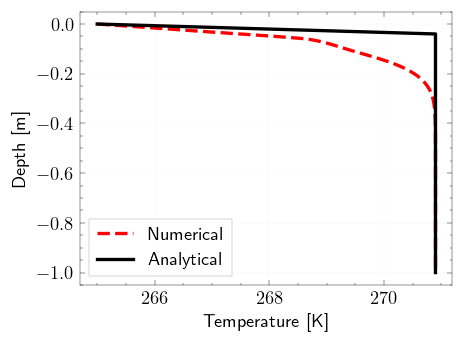

In [12]:
# preprocess the data
preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)
results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
# Note: analysis data inputs should not be changed!
analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )

#### Visualization of Model with VisualiseModel 

In [13]:
model_visualization_object = VisualiseModel(
    user_input_dataclass=userinput_data,
    results_dataclass=results_data,
    error_analysis_dataclass=analysis_data,
)

Visualisation object created...


In [14]:
# Plots the Temperature Difference between Analytical and Numerical Solutions
model_visualization_object.plot_error_temp(100, norm="inf", savefig=False)


Plotting Temperature errors using inf norm...


In [ ]:
# Plots the interface tracking over time for Analytical and Numerical Solutions
model_visualization_object.plot_depth_over_time(savefig=True)


### Example 2: Simulation with Hydra hierarchial and automation configuration

In [16]:
from pathlib import Path

from hydra import (
    compose,
    initialize,
)

from spyice.main_process import MainProcess

In [17]:
# choose your output directory
output_base_dir = Path("../example/output/with_hydra")

Model settings can be modified in the `example/conf` directory for:
- constants
- dt
- dz
- ICBC
- model

or in the  `overrides` option during initialize as seen in the next step.

To run the Sea-Ice Model using Hydra and the `MainProcess` script, users simply need to initialize Hydra, load the configuration file, specify any desired overrides, and then create an instance of the `MainProcess` class. The `run_model()` method is then called to execute the simulation. This streamlined process makes it simple for users to run the model with different configurations and analyze the results whose outputs are stored in **outputs** directory as .

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.
Running model...
Model run complete and Ready for Analysis.
Running error analysis...
Calculating errors...
Residuals exported successfully.
Postprocessing...
Visualisation object created...
Plotting Temperature heatmap...
Plotting Liquid-Fraction heatmap...
Postprocessing done.


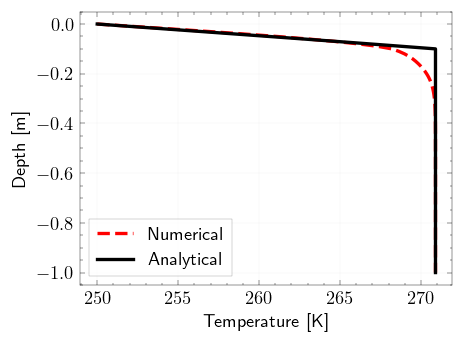

In [18]:
with initialize(version_base=None, config_path="conf"):
    cfg = compose(
        config_name="config.yaml",
        overrides=["iter_max=iter_max1500", "dt=dt47", "dz=dz0p01"],
    )
    out_hydra_dir = Path(output_base_dir, "with_hydra")
    main = MainProcess(cfg, out_hydra_dir)
    main.run_model()